# Task
Install the required libraries (`diffusers`, `transformers`, `accelerate`, `scipy`), load the "runwayml/stable-diffusion-v1-5" model, and generate an image based on a prompt.

## Install Dependencies

### Subtask:
Install the necessary Python libraries for running Stable Diffusion.


**Reasoning**:
Install the necessary Python libraries for running Stable Diffusion as specified in the instructions.



In [ ]:
!pip install diffusers transformers accelerate scipy

## Load Stable Diffusion Model

### Subtask:
Initialize the Stable Diffusion pipeline and move it to the GPU if available.


### Loading the Stable Diffusion Model

In this step, we will:
1.  **Detect the hardware**: Check if a GPU (CUDA) is available to accelerate image generation. If not, we fall back to the CPU.
2.  **Configure Precision**: Use `fp16` (half-precision) when running on a GPU to reduce memory usage and increase speed.
3.  **Initialize the Pipeline**: Load the weights for `runwayml/stable-diffusion-v1-5` into the `StableDiffusionPipeline`.
4.  **Transfer to Device**: Move the entire model pipeline to the selected device.

**Reasoning**:
I will initialize the Stable Diffusion pipeline by importing the necessary libraries, detecting the available device (GPU or CPU), setting the appropriate data type for memory optimization, and loading the model weights from Hugging Face.



In [ ]:
import torch
from diffusers import StableDiffusionPipeline

# Define the model identifier
model_id = "runwayml/stable-diffusion-v1-5"

# Check for GPU availability and set device and dtype
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Using device: {device} with dtype: {torch_dtype}")

# Load the pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch_dtype
)

# Move the pipeline to the device
pipe = pipe.to(device)

print("Stable Diffusion model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cpu with dtype: torch.float32


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion model loaded successfully.


**Reasoning**:
With the Stable Diffusion pipeline successfully loaded, I will now define a descriptive text prompt and use the pipeline to generate an image. I will also save and display the result.



Generating image for prompt: A futuristic city with cars at sunset between the mountians and above the ocean, highly detailed, cinematic lighting, realistic art art


  0%|          | 0/25 [00:00<?, ?it/s]

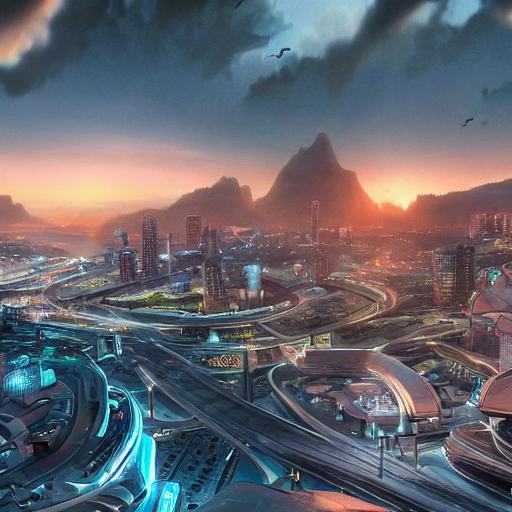

In [ ]:
# Define the prompt for the image you want to generate
prompt = "A futuristic city with cars at sunset between the mountians and above the ocean, highly detailed, cinematic lighting, realistic art art"

print(f"Generating image for prompt: {prompt}")

# Generate the image
# Note: On a CPU environment, this may take several minutes.
# num_inference_steps is set to 25 to balance speed and quality.
image = pipe(prompt, num_inference_steps=25).images[0]

# Save the generated image
image.save("generated_image.png")

# Display the image in the notebook
display(image)